## Лабораторная работа № 2 
## Машинное обучение на больших данных с использованием фреймворка Apache Spark и библиотеки SparkML

### Часть 2

В данной части работы рассмотрены:
* подготовка признаков для рашения задачи **градиентного бустинга** на деревьях решений;
* создание и обучение модели градиентного бустинга;
* оценка качества модели.

#### Запуск `Spark`-сессии

Подключаем необходимые библиотеки.

In [38]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.ml.feature import VectorAssembler, StringIndexer, Binarizer, Bucketizer
from pyspark.ml.functions import vector_to_array
from pyspark.ml.classification import RandomForestClassifier, RandomForestClassificationModel
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, CrossValidatorModel, ParamGridBuilder
from pyspark.ml import Pipeline
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.sql import Window
from pyspark.sql.functions import col, when

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """
    # Получаем имя пользователя
    # Получаем имя пользователя
    user_name = os.getenv("USER")
    
    conf = SparkConf()
    conf.setAppName("Lab_2_GB")
    conf.setMaster("local[*]")
    # conf.set("spark.submit.deployMode", "client")
    # КРИТИЧЕСКИЕ настройки памяти
    conf.set("spark.driver.memory", "8g")           # Увеличил драйвер
    conf.set("spark.executor.memory", "6g")         # Уменьшил исполнитель
    conf.set("spark.memory.fraction", "0.8")        # Больше для execution
    conf.set("spark.memory.storageFraction", "0.3") # Меньше для хранения
    
    # Настройки для больших данных
    conf.set("spark.sql.adaptive.enabled", "true")
    conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
    conf.set("spark.sql.adaptive.skew.enabled", "true")
    conf.set("spark.sql.shuffle.partitions", "100")  # Уменьшил партиции
    
    conf.set("spark.sql.catalog.spark_catalog.type", "hadoop")
    conf.set("spark.sql.catalog.spark_catalog.warehouse", f"hdfs:///b")
    conf.set("spark.sql.catalog.spark_catalog.io-impl", "org.apache.iceberg.hadoop.HadoopFileIO")

    return conf

Создаём сам объект конфигурации.

In [3]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`. В процессе создания сессии происходит подключение к кластеру `Apache Hadoop`, что может занять некоторое время.

In [4]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

#### Загрузка датасета

In [5]:
database_name = "vasilev_database"
table_name = "books_table_past_exp"

output_path = f"hdfs://namenode:9000/b/{database_name}/{table_name}"

df = spark.read.parquet(output_path)

def print_df(df):
    return df.limit(20).toPandas().style\
    .set_properties(**{'text-align': 'left', 'max-width': '0', 'white-space': 'nowrap', 'overflow': 'hidden', 'text-overflow': 'ellipsis'})\
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])\
    .format(precision=2)

Выведем прочитанную таблицу на экран.

In [6]:
print_df(df)

,id,title,authors,publisher,published_date,categories,review_score,review_text,review_summary,review_helpfulness,review_time,user_id,profile_name,helpfulness_numerator,helpfulness_denominator,helpfulness_ratio,published_date_clean,authors_array,categories_array,published_year,author_count,category_count,is_helpful,has_multiple_authors,has_multiple_categories,is_recent_review,review_text_length,review_summary_length,title_length,review_year,review_month,publisher_type,main_category
0,0710509413,"""""""Chosen"""" Classics: Round the World in Eighty Days""",ship,China,and America in one of the wittiest,['Jules Verne'],3.00,"Jules verne the author of Round the World in Eighty Days, which is a good science-fiction book, takes you into the world of Phileas Fogg. He is an englishman who wanted tosail around the world in the shortest amount of time inhis time which would be in the 1800s.I didn�t really like this book it was the one when you just start to drift off to sleep, because it is so boring.",Round the World in Eighty Days,1/1,1016668800,None,Anonymous,1,1,1.00,None,[' ship'],['Jules Verne'],0,1,1,1,0,0,0,383,30,53,2002,3,other,other
1,0710509413,"""""""Chosen"""" Classics: Round the World in Eighty Days""",ship,China,and America in one of the wittiest,['Jules Verne'],3.00,I very like this book and i wont that you send me the books and i very thenk to you.,round the world in eighty days,0/2,972604800,A1KAHINMSASLMP,ytai,0,2,0.00,None,[' ship'],['Jules Verne'],0,1,1,0,0,0,0,84,30,53,2000,10,other,other
2,B000KO9Q6A,"""""""Fundamentalism"""" and the Word of God""",Unknown,Unknown,None,Unknown,4.00,"JI Packer wrote this book over 45 years ago. Some of the issues he addresses are not issues today. But the premise behind the book is timeless- the authority of the Word of God. Even though liberalism may not be as strong as it was 50 years ago, today Christendom is wandering farther and farther away from the authority of God?s Word. This fact can be seen in the growth of cults. It can also be seen in how Christians today depend on human authors instead of God?s Word. Yet another manifestation of this wrong notion is the branch of Christianity that replaces God?s Word with emotion and feelings. So though the issue of Liberalism may not be significant today, the issue of authority definitely is.I read the book for a class on ?The History of Fundamentalism in America?. The book does not really trace the history of Fundamentalism, but the book does cover the central issue in the Fundamentalism/Liberalism debate. Before reading the book, I would suggest reading the first two pages of the conclusion, where the author gives an overview of the entire book. The book is very logically laid out, with each chapter subject building on top of the last chapter subject. The only chapter I had problems with was the chapter on faith. The author tries to explain man?s inability to express faith, showing the author?s reformed presuppositions. I didn?t understand how this tied into the argument and flow of the book, and I think the notion is unbiblical (but this is a discussion for a different book review). The main argument of the book was one of presuppositions (as found in presuppositional apologetics). On page 109 the author writes, ?We should not abandon faith in anything that God has taught us merely because we cannot solve all the problems which it raises. Our own intellectual competence is not the test and measure of divine truth. It is not for us to stop believing because we lack understanding, or to postpone believing till we can get understanding, but to believe in order that we may understand?? This is the core issue of authority- are we going to trust our own minds, or are we going to trust God?s Word?I would recommend the book to any Christian. The book will challenge you to take on a stronger stance for the Word of God, and it will show the foolishness of doing otherwise.","Perhaps Oudated, But Solid",13/14,1072224000,AOHKH73SA3ZK7,Josh Mof

Вспомним схему данных.

In [7]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- published_date: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- review_text: string (nullable = true)
 |-- review_summary: string (nullable = true)
 |-- review_helpfulness: string (nullable = true)
 |-- review_time: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- profile_name: string (nullable = true)
 |-- helpfulness_numerator: integer (nullable = true)
 |-- helpfulness_denominator: integer (nullable = true)
 |-- helpfulness_ratio: double (nullable = true)
 |-- published_date_clean: date (nullable = true)
 |-- authors_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- categories_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- published_year: integer (nullable = true)
 |-

Вычислим количество строк в датафрейме.

In [8]:
df.count()

2981716

#### Постановка задачи

Для датасета, заданного представленными колонками, требуется построить модель градиентного бустинга на деревьях решений для оценки факта того, является ли отзыв полезным, по всем остальным признакам.

Для оценки качества обучения следует использовать метрики Precision и Recall. Оценить максимально возможное значение точности при полноте не менее 60%.

#### Подготовка и кодирование признаков

Для корректной работы трансформеров и модели преобразуем столбец `helpfulness_ratio` к типу `DoubleType`, а столбец `is_helpful` к типу `IntegerType`.

Анализ потенциальной утечки данных

In [9]:
# Проверяем корреляцию helpfulness_ratio с целевой переменной
leakage_check = df.select(
    F.corr("helpfulness_ratio", "is_helpful").alias("corr_helpfulness_ratio"),
    F.corr("helpfulness_numerator", "is_helpful").alias("corr_numerator"),
    F.corr("helpfulness_denominator", "is_helpful").alias("corr_denominator")
).collect()[0]

print(f"Корреляция helpfulness_ratio с целевой: {leakage_check['corr_helpfulness_ratio']:.4f}")
print(f"Корреляция numerator с целевой: {leakage_check['corr_numerator']:.4f}")
print(f"Корреляция denominator с целевой: {leakage_check['corr_denominator']:.4f}")

Корреляция helpfulness_ratio с целевой: 0.9296
Корреляция numerator с целевой: 0.2199
Корреляция denominator с целевой: 0.1485


Выполним **стратифицированное** разделение датасета на обучающую и тестовую выборки.

In [10]:
def stratified_train_test_split(data: DataFrame, 
                                label_col: str,
                                ratio: float) -> tuple[DataFrame, DataFrame]:
    """
    Разделяет DataFrame на тренировочный и тестовый наборы с учетом стратификации.

    Args:
        data: Исходный DataFrame.
        label_col: Название столбца с меткой.
        ratio: Пропорция разделения данных.

    Returns:
        tuple[DataFrame, DataFrame]: Кортеж из тренировочного и тестового DataFrame.
    """
    # Проверяем корректность доли разделения
    assert (isinstance(ratio, float) and (0.0 <= ratio <= 1.0))
    
    # Формируем разделение для положительных и отрицательных объектов раздельно
    train_df_pos, test_df_pos = (data
                                 .filter(F.col(label_col) == 1)
                                 .randomSplit([ratio, 1 - ratio]))
    train_df_neg, test_df_neg = (data
                                 .filter(F.col(label_col) == 0)
                                 .randomSplit([ratio, 1 - ratio]))
    
    # Объединяем датафреймы
    return (train_df_pos.union(train_df_neg),
            test_df_pos.union(test_df_neg))

In [11]:
# Используем случайное разделение вместо стратифицированного
# чтобы избежать потенциальных проблем
train_ratio = 0.8
train_df, test_df = df.randomSplit([train_ratio, 1 - train_ratio], seed=42)

print(f"Размер обучающей выборки: {train_df.count()}")
print(f"Размер тестовой выборки: {test_df.count()}")

# Проверяем баланс в разделенных данных
print("\nБаланс классов в обучающей выборке:")
train_df.groupBy("is_helpful").count().show()

print("Баланс классов в тестовой выборке:")
test_df.groupBy("is_helpful").count().show()

Размер обучающей выборки: 2385082
Размер тестовой выборки: 596634

Баланс классов в обучающей выборке:
+----------+-------+
|is_helpful|  count|
+----------+-------+
|         1|1166930|
|         0|1218152|
+----------+-------+

Баланс классов в тестовой выборке:
+----------+------+
|is_helpful| count|
+----------+------+
|         1|291999|
|         0|304635|
+----------+------+



Закешируем сформированные датафреймы и проверим их объем.

In [12]:
train_df = train_df.cache()
test_df = test_df.cache()

print(f"Train dataset size: {train_df.count()}")
print(f"Test  dataset size: {test_df.count()}")

Train dataset size: 2385082
Test  dataset size: 596634


In [13]:
train_df.groupBy("is_helpful").count().show()

+----------+-------+
|is_helpful|  count|
+----------+-------+
|         1|1166930|
|         0|1218152|
+----------+-------+



Выполним балансировку датасета с помощью `oversampling`. 

In [14]:
def oversample(data: DataFrame, column: str) -> DataFrame:
    """
    Выполняет oversampling положительных классов в DataFrame.

    Args:
        data: Исходный DataFrame.
        column: Название столбца с меткой.

    Returns:
        DataFrame: Датафрейм с выполненным oversampling.
    """
    # Разделим датафрейм на положительные и отрицательные классы
    pos = data.filter(F.col(column) == 1.0)
    neg = data.filter(F.col(column) == 0.0)

    # Получим количество записей в каждом классе
    total_pos = pos.count()
    total_neg = neg.count()

    # Если количество положительных классов меньше отрицательных,
    # выполним oversampling
    if total_pos < total_neg:
        # Вычислим количество необходимых дубликатов
        num_duplicates = total_neg - total_pos

        # Дублируем положительные записи
        oversampled_pos = pos.withColumn(
            "dummy",
            F.explode(
                F.array_repeat(F.lit(1),
                               num_duplicates // total_pos + 1)
            )
        ).drop("dummy")

        # Объединим дублированные положительные записи с отрицательными
        balanced_df = neg.union(oversampled_pos)
    else:
        balanced_df = data

    return balanced_df

In [15]:
train_df = oversample(train_df, column="is_helpful")

Проверим баланс классов в получившемся датасете.

In [16]:
train_df.groupBy("is_helpful").count().show()

# Проверяем баланс классов после oversampling
print("Баланс классов после oversampling:")
train_balance = train_df.groupBy("is_helpful").count().collect()
for row in train_balance:
    print(f"Класс {row['is_helpful']}: {row['count']} записей "
          f"({row['count']/train_df.count()*100:.1f}%)")

# Если дисбаланс все еще большой, можно настроить oversampling

+----------+-------+
|is_helpful|  count|
+----------+-------+
|         0|1218152|
|         1|1166930|
+----------+-------+

Баланс классов после oversampling:
Класс 0: 1218152 записей (51.1%)
Класс 1: 1166930 записей (48.9%)


Остальные признаки сгруппируем по их типу:

* **Категориальные** признаки закодируем с помощью `label encoding`.
* **Бинарные** признаки представлены значениями `true` / `false`, которые могут быть интерпретированы как единица и нуль. Поэтому, в кодировании не нуждаются.
* **Количественные** признаки для древовидных моделей в кодировании не нуждаются.

In [17]:
# Убираем ВСЕ признаки, связанные с helpfulness - это утечка данных!
categorical_features = ["publisher_type", "main_category"]
binary_features = [
    "has_multiple_authors", 
    "has_multiple_categories", 
    "is_recent_review"
]
numeric_features = [
    "review_time", 
    "author_count", 
    "category_count", 
    "review_score"  # Добавляем review_score как числовой признак
]

print(f"Категориальные: {categorical_features}")
print(f"Бинарные: {binary_features}")
print(f"Числовые: {numeric_features}")

Категориальные: ['publisher_type', 'main_category']
Бинарные: ['has_multiple_authors', 'has_multiple_categories', 'is_recent_review']
Числовые: ['review_time', 'author_count', 'category_count', 'review_score']


In [18]:
# Добавляем новые признаки в списки
numeric_features.extend(["review_text_length", "review_summary_length", "title_length"])

# Проверяем корреляцию новых признаков с целевой переменной
new_features_check = df.select(
    F.corr("review_score", "is_helpful").alias("corr_review_score"),
    F.corr("review_text_length", "is_helpful").alias("corr_text_length"),
    F.corr("author_count", "is_helpful").alias("corr_author_count"),
    F.corr("category_count", "is_helpful").alias("corr_category_count")
).collect()[0]

print("\nКорреляция новых признаков с целевой переменной:")
print(f"review_score: {new_features_check['corr_review_score']:.4f}")
print(f"review_text_length: {new_features_check['corr_text_length']:.4f}")
print(f"author_count: {new_features_check['corr_author_count']:.4f}")
print(f"category_count: {new_features_check['corr_category_count']:.4f}")


Корреляция новых признаков с целевой переменной:
review_score: 0.0916
review_text_length: 0.2134
author_count: 0.0151
category_count: 0.0074


Создадим конвейер обработки данных, включающий модель градиентного бустинга на деревьях решений.

In [21]:
def create_pipeline(categorical_features: list[str], numeric_features: list[str], 
                    binary_features: list[str], label_col: str, max_depth: int = 4) -> Pipeline:
    
    # Для категориальных признаков с большим количеством значений используем StringIndexer с minFrequency
    string_indexer = StringIndexer(inputCols=categorical_features,
                                   outputCols=[f"{feature}_index" for feature in categorical_features],
                                   handleInvalid="keep",
                                   stringOrderType="frequencyDesc")
    
    # Объединяем все признаки
    all_features = [f"{feature}_index" for feature in categorical_features] + binary_features + numeric_features
    
    vector_assembler = VectorAssembler(
        inputCols=all_features,
        outputCol="features"
    )

    # Random Forest с правильными параметрами
    rf_classifier = RandomForestClassifier(
        featuresCol="features",
        labelCol=label_col,
        predictionCol="prediction",
        numTrees=50,           # Количество деревьев (аналог итераций в GBT)
        maxDepth=max_depth,    # Максимальная глубина деревьев
        maxBins=100,           # Увеличиваем для обработки категориальных признаков
        subsamplingRate=0.8,   # Доля данных для каждого дерева
        featureSubsetStrategy="auto",  # Стратегия выбора признаков
        seed=42
    )

    pipeline = Pipeline(stages=[
        string_indexer, vector_assembler, rf_classifier
    ])

    return pipeline

In [22]:
pipeline = create_pipeline(
    categorical_features=categorical_features,
    numeric_features=numeric_features,
    binary_features=binary_features,
    label_col="is_helpful",
    max_depth=4  # Вместо max_iter используем max_depth
)

#### Обучение модели

Выполним **подбор гиперпараметров** модели линейной регрессии с помощью кросс-валидации на сетке.

Создаем сетку параметров для кросс-валидации, получив объект `RandomForestClassifier` из конвейера.

In [24]:
param_grid = ParamGridBuilder() \
    .addGrid(pipeline.getStages()[-1].maxDepth, [3, 4, 5]) \
    .addGrid(pipeline.getStages()[-1].numTrees, [20, 30, 40]) \
    .addGrid(pipeline.getStages()[-1].subsamplingRate, [0.7, 0.8]) \
    .build()

Создаем экземпляр `BinaryClassificationEvaluator` для оценки модели.

In [25]:
cv_evaluator = BinaryClassificationEvaluator(labelCol="is_helpful")

Создаем объект `CrossValidator`.

In [26]:
cross_validator = CrossValidator(estimator=pipeline,
                                 estimatorParamMaps=param_grid,
                                 evaluator=cv_evaluator,
                                 numFolds=5)

Обучаем модель конвейера с использованием кросс-валидации.

In [27]:
cv_model = cross_validator.fit(train_df)

Exception ignored in: <function JavaWrapper.__del__ at 0x75d33d89a160>
Traceback (most recent call last):
  File "/usr/local/spark/python/pyspark/ml/wrapper.py", line 53, in __del__
    if SparkContext._active_spark_context and self._java_obj is not None:
                                              ^^^^^^^^^^^^^^
AttributeError: 'RandomForestClassifier' object has no attribute '_java_obj'


Выведем параметры **лучшей** модели, определенной в ходе кросс-валидации.

In [32]:
def get_best_model_params(cv_model: CrossValidatorModel) -> dict[str, any]:
    """
    Получает параметры лучшей модели из объекта CrossValidatorModel.

    Args:
        cv_model: Объект CrossValidatorModel, содержащий лучшую модель.

    Returns:
        Dict[str, any]: Параметры лучшей модели.
    """
    best_model = cv_model.bestModel
    rf_model = best_model.stages[-1]  # RandomForest модель
    
    best_params = {
        "maxDepth": rf_model.getMaxDepth,           # Без скобок!
        "numTrees": rf_model.getNumTrees,           # Без скобок!
        "subsamplingRate": rf_model.getSubsamplingRate,  # Без скобок!
        "featureSubsetStrategy": rf_model.getFeatureSubsetStrategy  # Без скобок!
    }
    return best_params

In [33]:
for key, value in get_best_model_params(cv_model=cv_model).items():
    print(f"{key}: {value}")

maxDepth: <bound method _DecisionTreeParams.getMaxDepth of RandomForestClassificationModel: uid=RandomForestClassifier_ef18a94075a8, numTrees=40, numClasses=2, numFeatures=12>
numTrees: 40
subsamplingRate: <bound method _TreeEnsembleParams.getSubsamplingRate of RandomForestClassificationModel: uid=RandomForestClassifier_ef18a94075a8, numTrees=40, numClasses=2, numFeatures=12>
featureSubsetStrategy: <bound method _TreeEnsembleParams.getFeatureSubsetStrategy of RandomForestClassificationModel: uid=RandomForestClassifier_ef18a94075a8, numTrees=40, numClasses=2, numFeatures=12>


#### Анализ обученной модели

Рассчитаем метрики на тестовом датасете.

In [34]:
# Получаем датасет предсказаний
test_df_predictions = cv_model.transform(test_df)

# Извлекаем список колонок, устанавливаем цену на последнее место
right_columns_order = test_df_predictions.columns
right_columns_order.remove("is_helpful")
right_columns_order.append("is_helpful")

# Изменяем последовательность колонок и выводим датафрейм
test_df_predictions = test_df_predictions.select(*right_columns_order)
print_df(test_df_predictions)

,id,title,authors,publisher,published_date,categories,review_score,review_text,review_summary,review_helpfulness,review_time,user_id,profile_name,helpfulness_numerator,helpfulness_denominator,helpfulness_ratio,published_date_clean,authors_array,categories_array,published_year,author_count,category_count,has_multiple_authors,has_multiple_categories,is_recent_review,review_text_length,review_summary_length,title_length,review_year,review_month,publisher_type,main_category,publisher_type_index,main_category_index,features,rawPrediction,probability,prediction,is_helpful
0,0001047655,The Prodigal Daughter,['Jeffrey Archer'],St. Martin's Paperbacks,2004-05-16,['Fiction'],1.00,"I first read ""Kane & Abel"" also by J. Archer, this one book was so good that even though I know that second parts are not as good as first parts I wanted to read it.This turn out to be an incredibly disapointing book, so much that I had to make a huge effort to keep reading and dont put the book on the trash.More than half of the book only repeats what we already knew from ""Kane & Abel"", and the rest was just the worst plot ever.How can someone writte so well first and then just be the worst writter ever?I just regret to have buy this book in the first place.",Extremly desapointing!!,4/15,1071446400,None,Anonymous,4,15,0.27,None,['Jeffrey Archer'],['Fiction'],0,1,1,0,0,0,593,23,21,2003,12,other,fiction,0.00,1.00,"[0.0,1.0,0.0,0.0,0.0,1071446400.0,1.0,1.0,1.0,593.0,23.0,21.0]","[18.80324523631924,21.19675476368076]","[0.470081130907981,0.529918869092019]",1.00,0
1,0001047655,The Prodigal Daughter,['Jeffrey Archer'],St. Martin's Paperbacks,2004-05-16,['Fiction'],1.00,"Life is too short to read this ongoing , never ending rubbish. My problems is i actually finished the book.",Dreadful. Never waste my time reading another jeffery archer,0/1,1355097600,A3A7K0060XADFT,Alba,0,1,0.00,None,['Jeffrey Archer'],['Fiction'],0,1,1,0,0,1,107,60,21,2012,12,other,fiction,0.00,1.00,"[0.0,1.0,0.0,0.0,1.0,1355097600.0,1.0,1.0,1.0,107.0,60.0,21.0]","[31.45540769839101,8.54459230160899]","[0.7863851924597752,0.21361480754022474]",0.00,0
2,0001047655,The Prodigal Daughter,['Jeffrey Archer'],St. Martin's Paperbacks,2004-05-16,['Fiction'],2.00,"After reading ""Not a penny more, not a penny less"", I was expecting a witty and sharp piece of work. Not so this time. Girl meets world, girls wants it, girl overcomes all kinds of obstacles, girl gets world. Yawn. ""Not a penny more..."" is a FANTASTIC book, if you've never read Archer before, start with that one. And pass on ""The Prodigal Daughter"".",Disappointing,2/5,901584000,A15BWCKYHH5PJ2,Some guy (me@myplace.com),2,5,0.40,None,['Jeffrey Archer'],['Fiction'],0,1,1,0,0,0,381,13,21,1998,7,other,fiction,0.00,1.00,"[0.0,1.0,0.0,0.0,0.0,901584000.0,1.0,1.0,2.0,381.0,13.0,21.0]","[25.01751708421504,14.982482915784958]","[0.625437927105376,0.37456207289462395]",0.00,0
3,0001047655,The Prodigal Daughter,['Jeffrey Archer'],St. Martin's Paperbacks,2004-05-16,['Fiction'],3.00,"""""""The Prodigal Daughter"""" focuses on the life of Florentyna Rosnovski Kane","""OK, but let down after """"Kane & Abel""""""",0/0,1315353600,A2H6Q6AK8S90F3,"""Kyle L. Rhynerson """"Fortitudine Vincimus""""""",0,0,0.00,None,['Jeffrey Archer'],['Fiction'],0,1,1,0,0,1,75,40,21,2011,9,other,fiction,0.00,1.00,"[0.0,1.0,0.0,0.0,1.0,1315353600.0,1.0,1.0,3.0,75.0,40.0,21.0]","[30.199572559561123,9.800427440438872]","[0.7549893139890282,0.24501068601097184]",0.00,0
4,0001047655,The Prodigal Daughter,['Jeffrey Archer'],St. Martin's Paperbacks,2004-05-16,['Fiction'],3.00,"I started to read this book and the first part (1934-1968) looked rather familiar. Indeed, it is a slightly modified rehash of a section in Kane and Abel. Fortunately, I read Kane and Abel some time ago and I forgot some of it. Not all of it, so I am again skipping many pages.Unfortunately, I was not aware of this prior to purchasing the book. I am trying to warn people who read Kane an Abel recently - the 

In [35]:
def evaluate_model(data: DataFrame, label_col: str) -> dict[str, float]:
    """
    Оценивает модель с использованием метрик точности, полноты и F1-score.
    Добавляет анализ матрицы ошибок.
    """
    # Вычисляем TP, FP, FN, TN
    tp = data.filter((F.col(label_col) == 1) & (F.col("prediction") == 1)).count()
    fp = data.filter((F.col(label_col) == 0) & (F.col("prediction") == 1)).count()
    fn = data.filter((F.col(label_col) == 1) & (F.col("prediction") == 0)).count()
    tn = data.filter((F.col(label_col) == 0) & (F.col("prediction") == 0)).count()

    # Вычисляем метрики
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0 else 0)
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

    # Выводим матрицу ошибок
    print("Матрица ошибок:")
    print(f"TP: {tp}, FP: {fp}")
    print(f"FN: {fn}, TN: {tn}")
    print(f"Всего записей: {data.count()}")

    # Возвращаем словарь с метриками
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy
    }

In [39]:
def evaluate_with_different_thresholds(predictions: DataFrame, label_col: str):
    """Оценка модели с разными порогами классификации"""
    print("\nОценка с разными порогами классификации:")
    print("Threshold | Precision | Recall   | F1       | Accuracy")
    print("-" * 55)
    
    for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
        threshold_predictions = predictions.withColumn(
            "prediction", 
            when(vector_to_array(F.col("probability")).getItem(1) > threshold, 1).otherwise(0)
        )
        
        metrics = evaluate_model(threshold_predictions, label_col)
        print(f"{threshold:8.2f} | {metrics['precision']:8.4f} | {metrics['recall']:8.4f} | "
              f"{metrics['f1']:8.4f} | {metrics['accuracy']:8.4f}")

# Применяем анализ порогов
evaluate_with_different_thresholds(test_df_predictions, "is_helpful")


Оценка с разными порогами классификации:
Threshold | Precision | Recall   | F1       | Accuracy
-------------------------------------------------------
Матрица ошибок:
TP: 272951, FP: 220187
FN: 19048, TN: 84448
Всего записей: 596634
    0.30 |   0.5535 |   0.9348 |   0.6953 |   0.5990
Матрица ошибок:
TP: 259685, FP: 186986
FN: 32314, TN: 117649
Всего записей: 596634
    0.40 |   0.5814 |   0.8893 |   0.7031 |   0.6324
Матрица ошибок:
TP: 211688, FP: 117096
FN: 80311, TN: 187539
Всего записей: 596634
    0.50 |   0.6439 |   0.7250 |   0.6820 |   0.6691
Матрица ошибок:
TP: 126535, FP: 49303
FN: 165464, TN: 255332
Всего записей: 596634
    0.60 |   0.7196 |   0.4333 |   0.5409 |   0.6400
Матрица ошибок:
TP: 0, FP: 0
FN: 291999, TN: 304635
Всего записей: 596634
    0.70 |   0.0000 |   0.0000 |   0.0000 |   0.5106


Наблюдаем довольно низкую точность при высокой полноте. Попробуем подобрать `threshold`, чтобы максимизировать точность, но при этом удерживать полноту на заданном в постановке задачи уровне.
Сначала рассчитаем `AUC ROC`, визуализируем `ROC` и `PR`-кривые и оценим ситуацию.

In [40]:
def calculate_auc_roc(model: RandomForestClassificationModel, 
                      test_data: DataFrame,
                      label_col: str) -> float:
    """
    Рассчитывает значение AUC ROC для модели.

    Args:
        model: Обученная модель классификации.
        test_data: Тестовый набор данных.
        label_col: Название столбца с меткой.

    Returns:
        float: Значение AUC ROC.
    """
    # Получаем прогнозы модели
    predictions = model.transform(test_data)

    # Создаем "оценщик" бинарной классификации
    evaluator = BinaryClassificationEvaluator(
        rawPredictionCol="rawPrediction",
        labelCol=label_col
    )

    # Вычисляем AUC ROC
    auc_roc = evaluator.evaluate(predictions)

    return auc_roc

In [41]:
def prepare_metrics_df(predictions: DataFrame, label_col: str) -> DataFrame:
    """
    Подготавливает DataFrame для расчета FPR, TPR и Precision.

    Args:
        predictions: DataFrame с прогнозами модели.
        label_col: Название столбца с меткой.

    Returns:
        DataFrame: DataFrame с рассчитанными столбцами FPR, TPR и Precision.
    """
    # Формируем датафрейм, содержащий результат предсказания,
    # вероятность предсказания и метку
    metrics_df = (
        predictions
        .select(
            vector_to_array(
                F.col("probability")
            ).getItem(1).alias("probability"),
            
            F.col(label_col).alias("label"),
            F.col("prediction").cast("int").alias("prediction")
        )
    )

    # Сортируем датафрейм по значениям вероятности
    metrics_df = metrics_df.orderBy("probability")

    # Рассчитываем количество положительных и отрицательных классов
    pos_count = metrics_df.filter(metrics_df.label == 1).count()
    neg_count = metrics_df.filter(metrics_df.label == 0).count()

    # Рассчитываем значения FPR и TPR
    window = Window.partitionBy().orderBy(F.desc("probability"))
    metrics_df = (
        metrics_df
        .withColumn("FP_cum", 
                    F.sum(F.when(
                        F.col("label") == 0, 1
                    ).otherwise(0)).over(window))
        .withColumn("TP_cum", F.sum(F.col("label")).over(window))
        .withColumn("FPR", F.col("FP_cum") / neg_count)
        .withColumn("TPR", F.col("TP_cum") / pos_count)
        .withColumn("Precision", 
                    F.col("TP_cum") / (F.col("TP_cum") + F.col("FP_cum")))
    )

    return metrics_df

In [42]:
def bucketize_metrics_df(metrics_df: DataFrame, 
                         num_buckets: int = 1000) -> DataFrame:
    """
    Применяет Bucketizer к DataFrame для уменьшения объёма данных, 
    возвращаемых на драйвер.

    Args:
        metrics_df: DataFrame с рассчитанными столбцами FPR, TPR и Precision.
        num_buckets: Количество бакетов.

    Returns:
        DataFrame: Бакетизированный Dataframe.
    """
    # Определяем границы бакетов
    bucketizer = Bucketizer(
        splits=list(np.linspace(0, 1, num_buckets + 1)),
        inputCol="probability",
        outputCol="bucket"
    )

    # Применяем Bucketizer
    metrics_df = bucketizer.setHandleInvalid("error").transform(metrics_df)

    # Формируем одну точку из каждого бакета
    metrics_df = metrics_df.groupBy("bucket").agg(
        F.avg(F.col("probability")).alias("probability"),
        F.avg(F.col("FPR")).alias("FPR"),
        F.avg(F.col("TPR")).alias("TPR"),
        F.avg(F.col("Precision")).alias("Precision")
    )

    return metrics_df

In [44]:
def calculate_metrics(model: RandomForestClassificationModel, 
                      test_data: DataFrame,
                      label_col: str) -> pd.DataFrame:
    """
    Рассчитывает значения FPR, TPR и Precision для построения ROC и PR-кривых.

    Args:
        model: Обученная модель классификации.
        test_data: Тестовый набор данных.
        label_col: Название столбца с меткой.

    Returns:
        tuple[float, pd.DataFrame]: Кортеж из значения AUC ROC и DataFrame 
                                    со значениями FPR, TPR и Precision.
    """
    # Получаем прогнозы модели
    predictions = model.transform(test_data)

    # Подготавливаем DataFrame для расчета FPR, TPR и Precision
    metrics_df = prepare_metrics_df(predictions, label_col)

    # Применяем Bucketizer к DataFrame
    metrics_df = bucketize_metrics_df(metrics_df)

    return metrics_df.toPandas()

In [45]:
def plot_roc_pr_curves(pd_data: pd.DataFrame, 
                       auc_roc: float) -> None:
    """
    Визуализирует ROC и PR-кривые, добавляет на график AUC ROC.

    Args:
        pd_data: Pandas DataFrame, содержащий столбцы 
            "FPR", "TPR", "Precision".
        auc_roc: Значение AUC-ROC.

    Returns:
        None
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Построение ROC-кривой
    sns.lineplot(x="FPR", y="TPR", data=pd_data, ax=axes[0])
    sns.lineplot(x=[0, 1], y=[0, 1], 
                 color="gray", linestyle="--", ax=axes[0])
    axes[0].set_xlabel("False Positive Rate (FPR)")
    axes[0].set_ylabel("True Positive Rate (TPR)")
    axes[0].set_title("ROC Curve")
    axes[0].grid()

    # Добавляем значение AUC-ROC в правом нижнем углу графика
    axes[0].text(0.94, 0.06, f'AUC-ROC: {auc_roc:.2f}', 
                 transform=axes[0].transAxes,
                 fontsize=12, verticalalignment='bottom', 
                 horizontalalignment='right',
                 bbox=dict(facecolor='white', 
                           alpha=0.8), zorder=5)

    # Построение PR-кривой
    sns.lineplot(x="TPR", y="Precision", 
                 data=pd_data, ax=axes[1])
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("PR Curve")
    axes[1].grid()

    plt.tight_layout()
    plt.show()

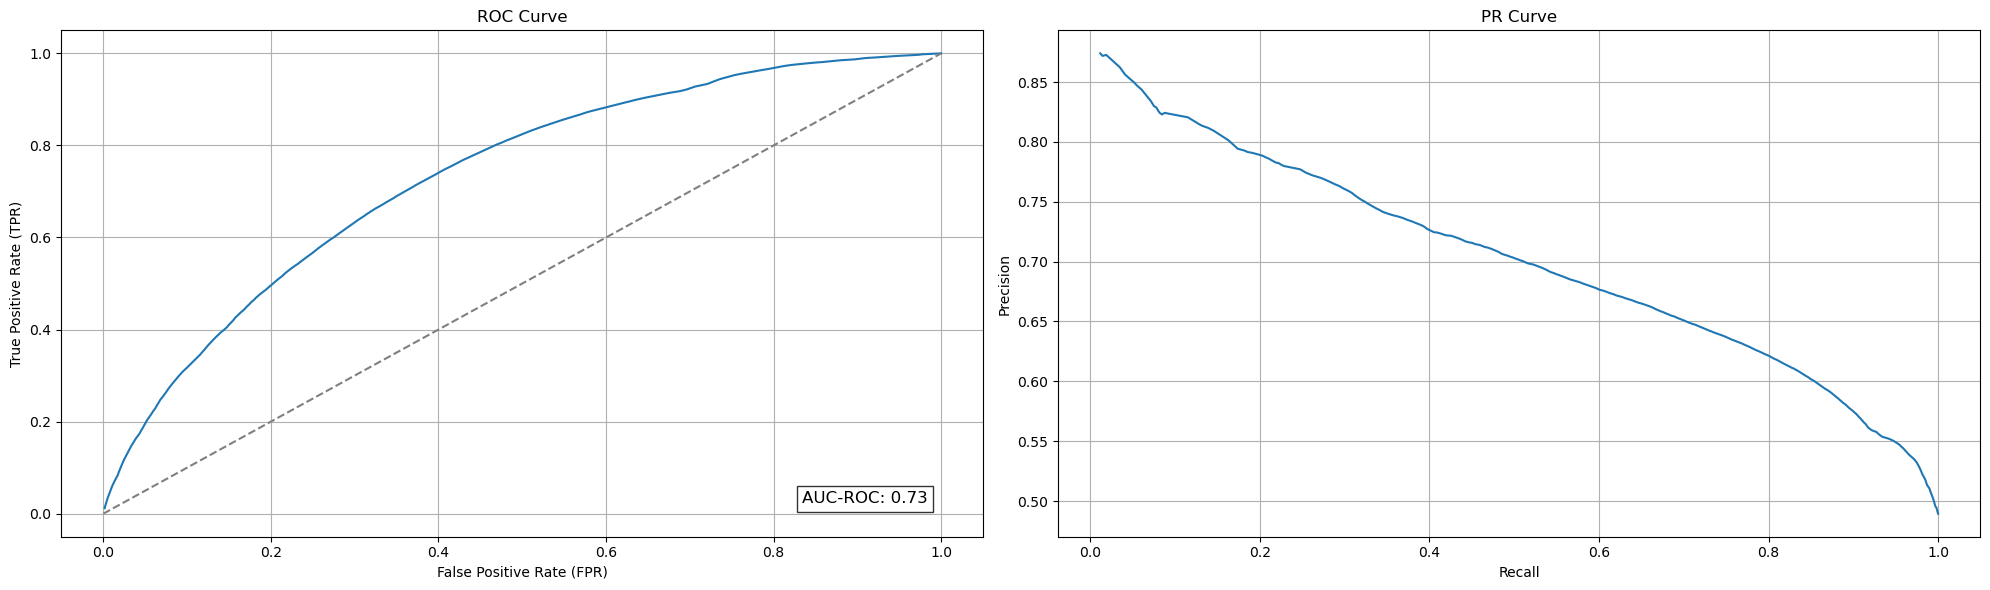

In [46]:
# Рассчитываем AUC ROC
auc_roc = calculate_auc_roc(model=cv_model,
                            test_data=test_df,
                            label_col="is_helpful")
pd_dataframe = calculate_metrics(model=cv_model,
                                 test_data=test_df,
                                 label_col="is_helpful")
plot_roc_pr_curves(pd_dataframe, auc_roc)

Определим вероятность -- границу разделения, при которой `Recall` не меньше 60%.

In [47]:
threshold_probability = pd_dataframe[pd_dataframe['TPR'] >= 0.60]['probability'].max()
print(f"Вероятность -- граница разделения, при которой TPR не меньше 60%: {threshold_probability:.2f}")

Вероятность -- граница разделения, при которой TPR не меньше 60%: 0.55


Рассчитаем метрики на тестовом датасете повторно, с учетом вычисленного `threshold` для вероятности.

In [48]:
cv_model.bestModel.stages[-1].setThresholds([1 - threshold_probability, 
                                             threshold_probability])
test_df_predictions = cv_model.transform(test_df)
metrics = evaluate_model(test_df_predictions, "is_helpful")
print(f"Metrics: {metrics}")

Матрица ошибок:
TP: 175739, FP: 84134
FN: 116260, TN: 220501
Всего записей: 596634
Metrics: {'precision': 0.67624955266611, 'recall': 0.6018479515340805, 'f1': 0.6368831903049982, 'accuracy': 0.6641257454318729}


Не забываем завершать `Spark`-сессию.

In [49]:
spark.stop()